In [42]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, ResNet50V2, DenseNet121, EfficientNetB0
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
 )
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [43]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU disponible: {len(gpus)} dispositivo(s)")
    except RuntimeError as e:
        print(e)
else:
    print("Usando CPU")


GPU disponible: 1 dispositivo(s)


In [44]:
MODEL_NAME = "EfficientNetB0"

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass", "No Finding",
    "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"
]

NUM_CLASSES = len(LABEL_COLS)
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
THRESHOLD = 0.7
IMG_SIZE = (224, 224)

print(f"MODELO SELECCIONADO: {MODEL_NAME}")
print(f"Número de clases: {NUM_CLASSES}")
print(f"Tamaño de imagen: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Épocas: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

MODELO SELECCIONADO: EfficientNetB0
Número de clases: 15
Tamaño de imagen: (224, 224)
Batch size: 16
Épocas: 10
Learning rate: 0.0001


In [73]:
class CustomDataGenerator(keras.utils.Sequence):

    def __init__(self, df, img_dir, batch_size=32, img_size=(224, 224),
                 augment=False, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.label_cols = LABEL_COLS
        self.indexes = np.arange(len(self.df))

        if self.augment:
            self.datagen = ImageDataGenerator(
                horizontal_flip=True,
                rotation_range=10,
            )
        else:
            self.datagen = None
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[indexes]

        X, y = self._generate_data(batch_df)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def _generate_data(self, batch_df):
        batch_size = len(batch_df)
        X = np.zeros((batch_size, *self.img_size, 3), dtype=np.float32)
        y = np.zeros((batch_size, NUM_CLASSES), dtype=np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            img_path = os.path.join(self.img_dir, row['Image Index'])
            img = keras.preprocessing.image.load_img(img_path, target_size=self.img_size)
            img_array = keras.preprocessing.image.img_to_array(img)

            if self.datagen is not None:
                img_array = self.datagen.random_transform(img_array)
            X[i] = img_array
            y[i] = row[self.label_cols].astype(np.float32).values

        X = keras.applications.efficientnet.preprocess_input(X)
        return X, y

In [74]:
images_path = f"{path}/sample/images/"

len(os.listdir(images_path))

5606

In [75]:

df = pd.read_csv("sample_labels_processed.csv")
df = df.drop(columns=['Finding Labels'], errors='ignore')

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

print(f"\nTamaño train: {len(train_df)}")
print(f"Tamaño test: {len(test_df)}")

IMG_DIR = images_path

train_generator = CustomDataGenerator(
    train_df, IMG_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    augment=True,
    shuffle=True
)

test_generator = CustomDataGenerator(
    test_df, IMG_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

print(f"Batches de entrenamiento: {len(train_generator)}")
print(f"Batches de test: {len(test_generator)}")


Tamaño train: 4485
Tamaño test: 1121
Batches de entrenamiento: 281
Batches de test: 71


In [76]:
def create_model(model_name, num_classes=NUM_CLASSES):

    keras.backend.clear_session()

    if model_name == "EfficientNetB0":
        base_model = EfficientNetB0(weights='imagenet', include_top=False,
                             input_shape=(*IMG_SIZE, 3))
    else:
        raise ValueError(f"Modelo {model_name} no soportado")

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print(f"Creando modelo: {MODEL_NAME}")

model = create_model(MODEL_NAME)
print(f"Parámetros totales: {model.count_params():,}")
print(f"Parámetros entrenables: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

model.summary()

Creando modelo: EfficientNetB0
Parámetros totales: 4,068,786
Parámetros entrenables: 4,026,763


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 4,026,763 (15.36 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [63]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        f'best_{MODEL_NAME}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [77]:

print(f"ENTRENANDO {MODEL_NAME}")

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    # callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("RESUMEN DE ENTRENAMIENTO")
print(f"Pérdida final (train): {train_loss:.4f}")
print(f"Pérdida final (val):   {val_loss:.4f}")
print(f"Accuracy final (train): {train_acc:.4f}")
print(f"Accuracy final (val):   {val_acc:.4f}")


ENTRENANDO EfficientNetB0


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.4198 - loss: 0.3933

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


281/281 ━━━━━━━━━━━━━━━━━━━━ 277s 736ms/step - accuracy: 0.4201 - loss: 0.3929 - val_accuracy: 0.5183 - val_loss: 0.2120
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 143s 508ms/step - accuracy: 0.5432 - loss: 0.1984 - val_accuracy: 0.5049 - val_loss: 0.2022
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 137s 487ms/step - accuracy: 0.5447 - loss: 0.1913 - val_accuracy: 0.5299 - val_loss: 0.2007
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 140s 499ms/step - accuracy: 0.5560 - loss: 0.1826 - val_accuracy: 0.5290 - val_loss: 0.2009
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 136s 484ms/step - accuracy: 0.5579 - loss: 0.1774 - val_accuracy: 0.5192 - val_loss: 0.2014
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 139s 494ms/step - accuracy: 0.5671 - loss: 0.1723 - val_accuracy: 0.5335 - val_loss: 0.1999
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 136s 483ms/step - accuracy: 0.5920 - loss: 0.1612 - val_accuracy: 0.5352 - val_loss: 0.2068
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 137s 488ms/step - accuracy: 0.6051 - loss: 0.15

In [78]:
def find_best_thresholds(y_true, y_pred):
    thresholds = []
    for i in range(y_true.shape[1]):
        precisions, recalls, ths = precision_recall_curve(y_true[:, i], y_pred[:, i])
        f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        best_th = ths[np.argmax(f1s)]
        thresholds.append(best_th)
    return np.array(thresholds)

In [79]:
y_true_list, y_pred_list = [], []
for i in range(len(test_generator)):
    X, y = test_generator[i]
    preds = model.predict(X, verbose=0)
    y_true_list.append(y)
    y_pred_list.append(preds)
y_true = np.vstack(y_true_list)
y_pred = np.vstack(y_pred_list)
best_thresholds = find_best_thresholds(y_true, y_pred)
print("Umbrales óptimos por clase:\n")
for cls, th in zip(LABEL_COLS, best_thresholds):
    print(f"{cls:20s} {th:.3f}")

Umbrales óptimos por clase:

Atelectasis          0.433
Cardiomegaly         0.122
Consolidation        0.165
Edema                0.541
Effusion             0.178
Emphysema            0.160
Fibrosis             0.164
Hernia               0.014
Infiltration         0.100
Mass                 0.250
No Finding           0.471
Nodule               0.066
Pleural_Thickening   0.049
Pneumonia            0.060
Pneumothorax         0.110


In [86]:
def evaluate_model(model, generator, class_names=None, thresholds=None):

    print("EVALUACIÓN DETALLADA")
    print("Generando predicciones...")

    y_true = []
    y_pred = []

    for i in tqdm(range(len(generator)), desc="Evaluando"):
        X_batch, y_batch = generator[i]
        pred_batch = model.predict(X_batch, verbose=0)
        y_true.append(y_batch)
        y_pred.append(pred_batch)

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    aucs, accs, precisions, recalls, f1s = [], [], [], [], []
    num_classes = y_true.shape[1]

    for i in range(num_classes):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        except ValueError:
            auc = np.nan
        aucs.append(auc)

        y_pred_bin = (y_pred[:, i] >= thresholds[i]).astype(int)

        accs.append(accuracy_score(y_true[:, i], y_pred_bin))
        precisions.append(precision_score(y_true[:, i], y_pred_bin, zero_division=0))
        recalls.append(recall_score(y_true[:, i], y_pred_bin, zero_division=0))
        f1s.append(f1_score(y_true[:, i], y_pred_bin, zero_division=0))

    auc_mean = np.nanmean(aucs)
    acc_mean = np.mean(accs)
    prec_mean = np.mean(precisions)
    rec_mean = np.mean(recalls)
    f1_mean = np.mean(f1s)

    if class_names is None:
        class_names = [f'Clase_{i}' for i in range(num_classes)]

    metrics_df = pd.DataFrame({
        'Clase': class_names,
        'AUC': np.round(aucs, 4),
        'Accuracy': np.round(accs, 4),
        'Precision': np.round(precisions, 4),
        'Recall': np.round(recalls, 4),
        'F1-Score': np.round(f1s, 4)
    }).sort_values(by='AUC', ascending=False)

    print("RESULTADOS GLOBALES")
    print(f"AUC promedio:       {auc_mean:.4f}")
    print(f"Accuracy promedio:  {acc_mean:.4f}")
    print(f"Precision promedio: {prec_mean:.4f}")
    print(f"Recall promedio:    {rec_mean:.4f}")
    print(f"F1 promedio:        {f1_mean:.4f}")
    print(f"\nMétricas por clase (umbral = {thresholds})")
    display(metrics_df)

    return auc_mean, acc_mean, prec_mean, rec_mean, f1_mean, metrics_df

In [88]:
auc_mean, acc_mean, prec_mean, rec_mean, f1_mean, metrics_df = evaluate_model(model, test_generator, class_names=LABEL_COLS, thresholds=best_thresholds)

EVALUACIÓN DETALLADA
Generando predicciones...


Evaluando: 100%|██████████| 71/71 [00:24<00:00,  2.93it/s]


RESULTADOS GLOBALES
AUC promedio:       0.7306
Accuracy promedio:  0.8837
Precision promedio: 0.2545
Recall promedio:    0.3502
F1 promedio:        0.2603

Métricas por clase (umbral = [0.43310723 0.12179214 0.16452463 0.54132074 0.17777072 0.15987888
 0.16445544 0.01439868 0.0996489  0.24978441 0.47118127 0.06550156
 0.0488295  0.06036083 0.10985969])


,Clase,AUC,Accuracy,Precision,Recall,F1-Score
5,Emphysema,0.8186,0.9723,0.2727,0.2857,0.2791
3,Edema,0.8012,0.9831,0.5000,0.1053,0.1739
14,Pneumothorax,0.7833,0.9001,0.2432,0.4909,0.3253
1,Cardiomegaly,0.7798,0.9135,0.1705,0.3846,0.2362
2,Consolidation,0.7783,0.9153,0.1842,0.2979,0.2276
4,Effusion,0.7775,0.8046,0.3156,0.5221,0.3934
0,Atelectasis,0.7690,0.8608,0.2681,0.4022,0.3217
9,Mass,0.7433,0.9402,0.4118,0.2295,0.2947
7,Hernia,0.7302,0.9661,0.0270,0.3333,0.0500
6,Fibrosis,0.7262,0.9813,0.2000,0.0556,0.0870


In [84]:

metrics_df.to_csv(f"metrics_{MODEL_NAME}.csv", index=False)
print(f"\nMétricas guardadas en 'metrics_{MODEL_NAME}.csv'")

model.save(f"model_{MODEL_NAME}.keras")
print(f"Modelo guardado en 'model_{MODEL_NAME}.keras'")

summary = {
    "Modelo": MODEL_NAME,
    "Epochs": EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Threshold": THRESHOLD,
    "Train Loss": train_loss,
    "Val Loss": val_loss,
    "Train Accuracy": train_acc,
    "Val Accuracy": val_acc,
    "AUC promedio": auc_mean,
    "Accuracy promedio": acc_mean,
    "Precision promedio": prec_mean,
    "Recall promedio": rec_mean,
    "F1 promedio": f1_mean
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"summary_{MODEL_NAME}.csv", index=False)
print(f"Resumen guardado en 'summary_{MODEL_NAME}.csv'")
print("PROCESO COMPLETADO")


Métricas guardadas en 'metrics_EfficientNetB0.csv'
Modelo guardado en 'model_EfficientNetB0.keras'
Resumen guardado en 'summary_EfficientNetB0.csv'
PROCESO COMPLETADO


In [89]:
loaded_model = keras.models.load_model(f"model_{MODEL_NAME}.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


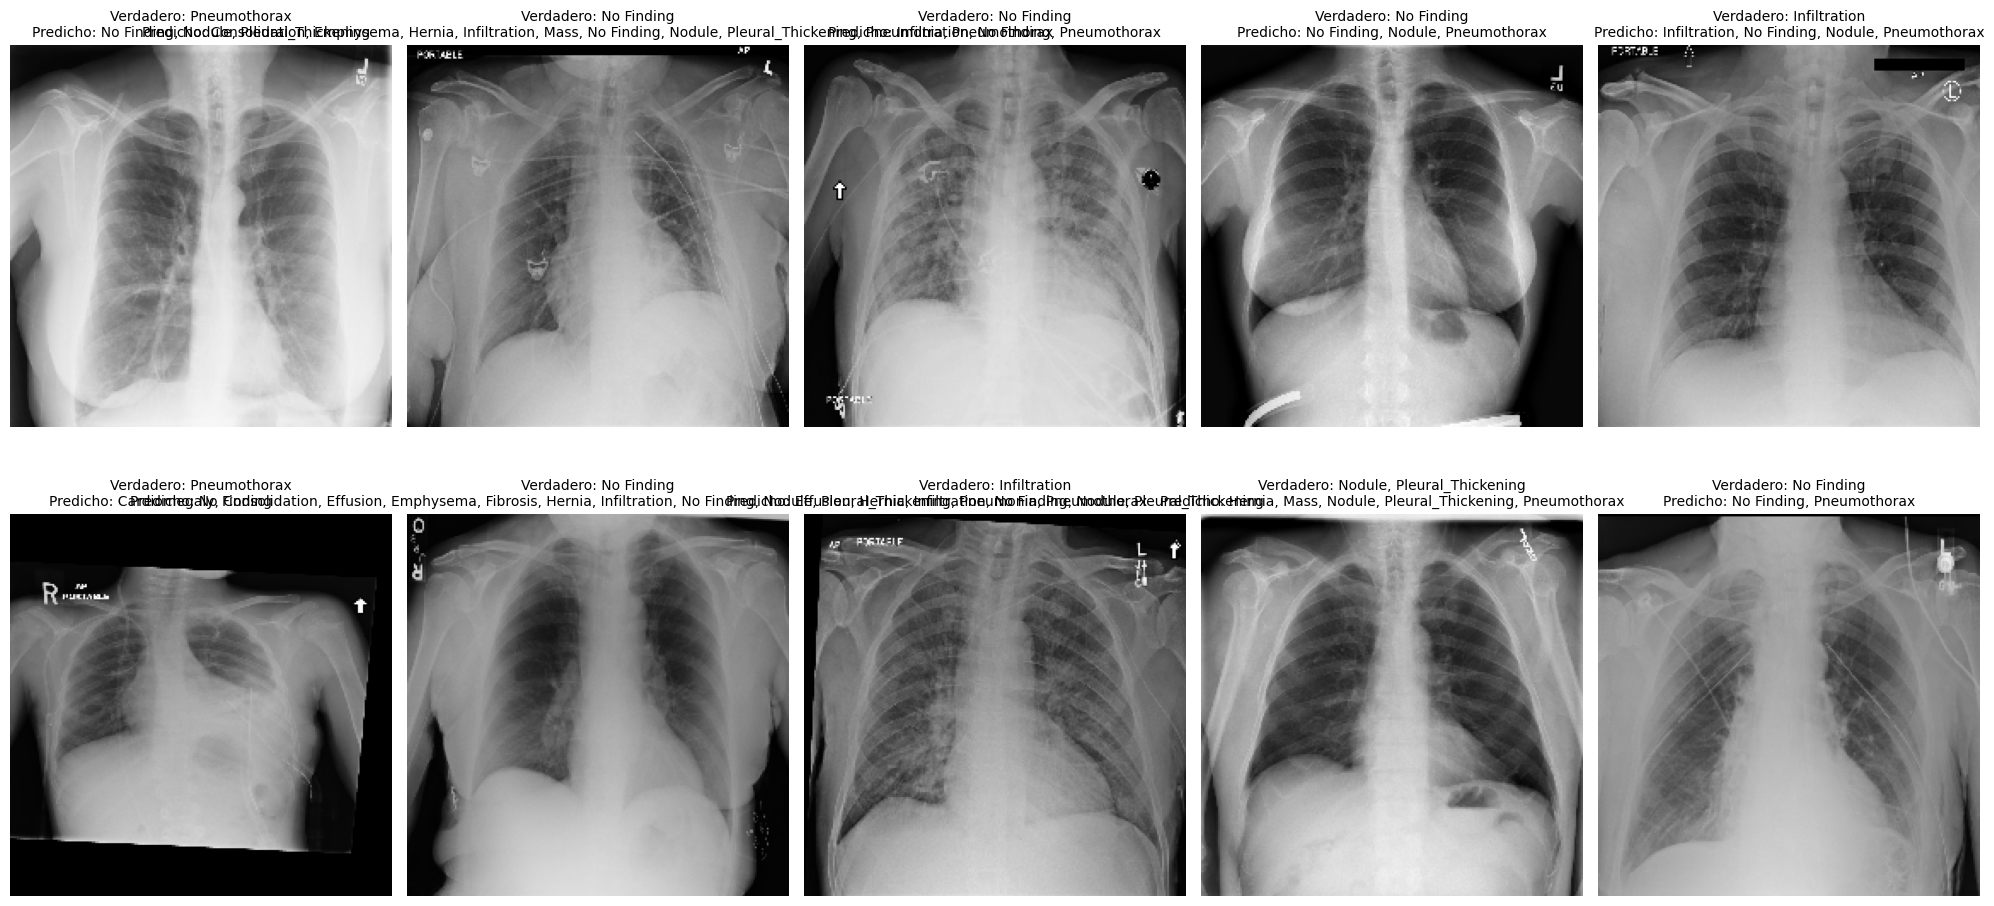

In [92]:
sample_df = test_df.sample(n=10).reset_index(drop=True)

plt.figure(figsize=(20, 10))
for i, row in sample_df.iterrows():
    img_path = os.path.join(IMG_DIR, row['Image Index'])
    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = keras.applications.resnet50.preprocess_input(img_array)

    pred = loaded_model.predict(img_array)[0]
    pred_labels = [LABEL_COLS[j] for j, p in enumerate(pred) if p >= best_thresholds[j]]
    true_labels = [LABEL_COLS[j] for j, v in enumerate(row[LABEL_COLS].values) if v == 1]

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {', '.join(true_labels)}\nPredicho: {', '.join(pred_labels)}", fontsize=10)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


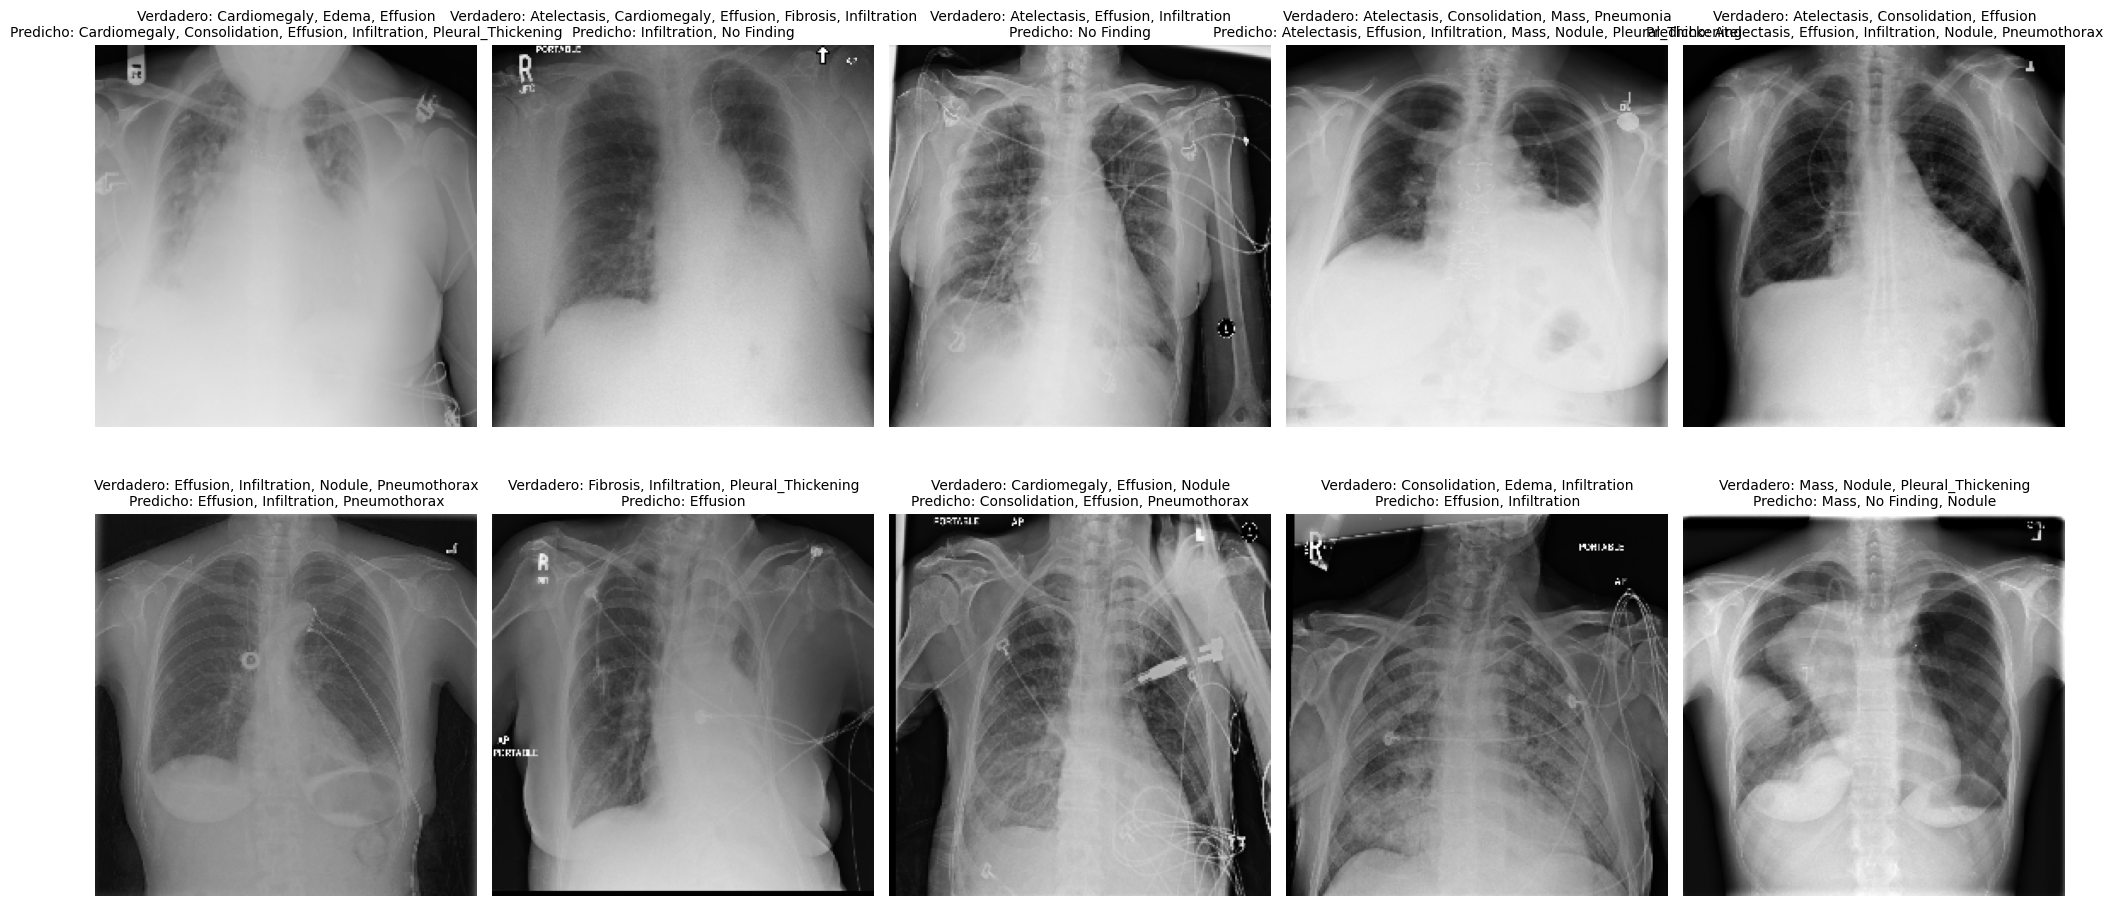

In [93]:
multi_label_df = test_df[test_df[LABEL_COLS].sum(axis=1) > 2]

sample_df = multi_label_df.sample(n=min(10, len(multi_label_df)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(20, 10))
for i, row in sample_df.iterrows():
    img_path = os.path.join(IMG_DIR, row['Image Index'])
    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = keras.applications.efficientnet.preprocess_input(img_array)

    pred = loaded_model.predict(img_array)[0]
    pred_labels = [LABEL_COLS[j] for j, p in enumerate(pred) if p >= best_thresholds[j]]
    true_labels = [LABEL_COLS[j] for j, v in enumerate(row[LABEL_COLS].values) if v == 1]

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {', '.join(true_labels)}\nPredicho: {', '.join(pred_labels)}", fontsize=10)

plt.tight_layout()
plt.show()